# Import libraries 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.cluster import KMeans # Here is where you import the k-means algorithm from scikit-learn.
import pylab as pl # PyLab is a convenience module that bulk imports matplotlib.

In [2]:
# This option ensures the graphs you create are displayed in your notebook without the need to "call" them specifically.

%matplotlib inline

# import dataframes

In [3]:
#Identify path 
data_path= '../02 Data/'
vis_path= '../04 Analysis/'

In [4]:
# import geo merged dataframe
df=pd.read_pickle(os.path.join(data_path,'Prepared Data','health_geo_merged.pkl'))

In [5]:
# check df
df.head()

,country,geometry,country_name,Time,hospital_stay,mri_units,ct_scanners,hospital_beds
0,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1992,6.6,1.43,16.71,1.43
1,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1994,6.4,2.36,18.48,2.36
2,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1995,6.5,2.89,20.55,2.89
3,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1996,6.4,2.96,21.95,2.96
4,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1997,6.2,3.53,23.34,3.53


In [6]:
df.shape

(518, 8)

In [8]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   country        518 non-null    object  
 1   geometry       518 non-null    geometry
 2   country_name   518 non-null    object  
 3   Time           518 non-null    int64   
 4   hospital_stay  518 non-null    float64 
 5   mri_units      518 non-null    float64 
 6   ct_scanners    518 non-null    float64 
 7   hospital_beds  518 non-null    float64 
dtypes: float64(4), geometry(1), int64(1), object(2)
memory usage: 32.5+ KB


## creating subgroup of non-categorical columns for k-means analysis

In [17]:
df2= df[['hospital_stay','mri_units','ct_scanners','hospital_beds','Time']]

In [18]:
df2.describe()

,hospital_stay,mri_units,ct_scanners,hospital_beds,Time
count,518.000000,518.000000,518.000000,518.000000,518.000000
mean,7.140154,10.565502,19.646718,10.565502,2007.967181
std,2.566864,8.685570,14.352069,8.685570,6.944160
min,3.400000,0.100000,1.480000,0.100000,1990.000000
25%,5.800000,4.072500,10.332500,4.072500,2003.250000
50%,6.650000,8.765000,15.375000,8.765000,2009.000000
75%,7.500000,13.877500,26.592500,13.877500,2014.000000
max,32.700000,55.210000,111.490000,55.210000,2018.000000


## Elbow technique

In [20]:
# define the ranfe of potential clusters in the data
num_cl= range(1,10) 
# defines k-means clusters in the range assigned above
kmeans= [KMeans(n_clusters=i) for i in num_cl]

In [22]:
# Creates a score that represents 
# a rate of variation for the given cluster option.
score= [kmeans[i].fit(df2).score(df2) for i in range(len(kmeans))]

In [23]:
score

[-212833.55133243243,
 -158885.85730176128,
 -80063.63291355492,
 -56178.62158148484,
 -44624.56582224894,
 -39217.14668121903,
 -35008.01619758362,
 -28084.56926212038,
 -25378.89798921912]

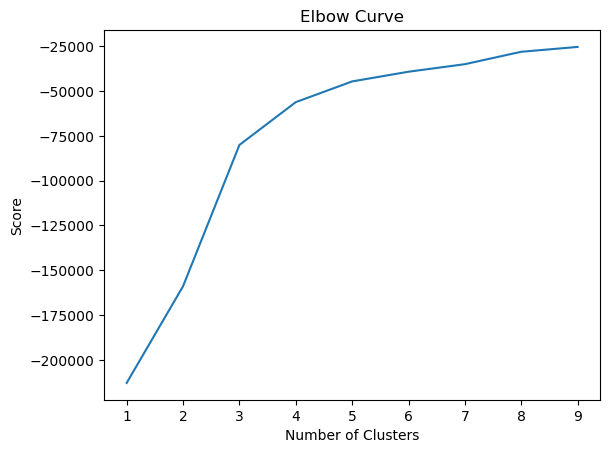

In [24]:
# plot the elbow curve using Pylab
pl.plot(num_cl,score)
pl.xlabel('Number of Clusters')
pl.ylabel('Score')
pl.title('Elbow Curve')
pl.show()

### comment:
In this example, there's a large jump from two to four on the x-axis, but after that, the curve straightens out. This means that the optimal count for your clusters is four.

## k-means clustering 

In [78]:
# Create the k-means object.
# number is determained by the function above

kmeans = KMeans(n_clusters = 4) 


In [79]:
# Fit the k-means object to the data.

kmeans.fit(df2)

ValueError: could not convert string to float: 'medium purple'

In [27]:
df2['clusters']=kmeans.fit_predict(df2)

/var/folders/tg/yb04v51d0cz5ntssvndh4znw0000gn/T/ipykernel_48741/14018863.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['clusters']=kmeans.fit_predict(df2)


In [30]:
df2.head()

,hospital_stay,mri_units,ct_scanners,hospital_beds,Time,clusters
0,6.6,1.43,16.71,1.43,1992,2
1,6.4,2.36,18.48,2.36,1994,2
2,6.5,2.89,20.55,2.89,1995,2
3,6.4,2.96,21.95,2.96,1996,2
4,6.2,3.53,23.34,3.53,1997,2


In [31]:
df2['clusters'].value_counts()

clusters
0    230
2    170
1    111
3      7
Name: count, dtype: int64

In [77]:
# Plot the clusters for the "ct scanners" and "hospital beds" variables.

ct_bed_cluster= plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df2['ct_scanners'], y=df2['hospital_beds'], hue=kmeans.labels_, s=100) 
# Here, you're subsetting `X` for the x and y arguments to avoid using their labels. 
# `hue` takes the value of the attribute `kmeans.labels_`, which is the result of running the k-means algorithm.
# `s` represents the size of the points you want to see in the plot.

ax.grid(False) # This removes the grid from the background.
plt.xlabel('CT Scanners') # Label x-axis.
plt.ylabel('Hospital Beds') # Label y-axis.
plt.show()

ValueError: array length 32 does not match index length 518

<Figure size 1200x800 with 0 Axes>

In [41]:
# export
ct_bed_cluster.figure.savefig(os.path.join(vis_path,'Visuals','ct bed cluster'), bbox_inches='tight')

In [75]:
# Plot the clusters for the "ct scanners" and "hospital beds" country

ct_bed_con_cluster= plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df2['ct_scanners'], y=df2['hospital_beds'], hue=kmeans.labels_, s=100) 
# Here, you're subsetting `X` for the x and y arguments to avoid using their labels. 
# `hue` takes the value of the attribute `kmeans.labels_`, which is the result of running the k-means algorithm.
# `s` represents the size of the points you want to see in the plot.

ax.grid(False) # This removes the grid from the background.
plt.xlabel('CT Scanners') # Label x-axis.
plt.ylabel('Hospital Beds') # Label y-axis.
plt.show()

ValueError: array length 32 does not match index length 518

<Figure size 1200x800 with 0 Axes>

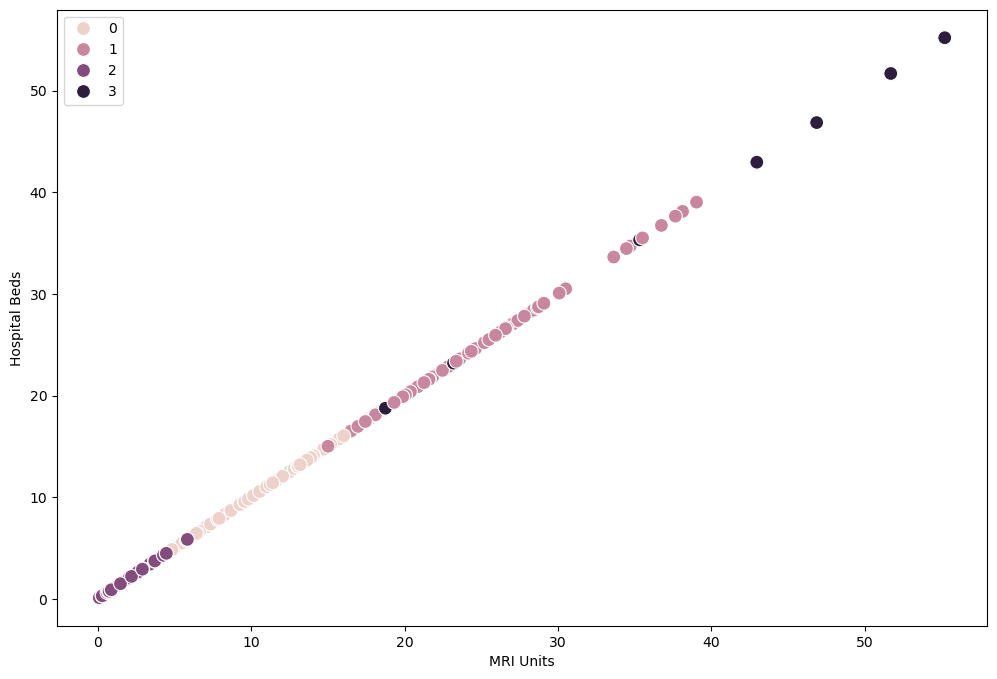

In [42]:
# Plot the clusters for the "MRI Units" and "Hospital Beds" variables.

mri_bed=plt.figure(figsize=(12,8))
ax = sns.scatterplot(x=df2['mri_units'], y=df2['hospital_beds'], hue=kmeans.labels_, s=100) 
# Here, you're subsetting `X` for the x and y arguments to avoid using their labels. 
# `hue` takes the value of the attribute `kmeans.labels_`, which is the result of running the k-means algorithm.
# `s` represents the size of the points you want to see in the plot.

ax.grid(False) # This removes the grid from the background.
plt.xlabel('MRI Units') # Label x-axis.
plt.ylabel('Hospital Beds') # Label y-axis.
plt.show()

In [43]:
# export
mri_bed.figure.savefig(os.path.join(vis_path,'Visuals','mri bed cluster'), bbox_inches='tight')

In [64]:
#combing the clusters to get statistical information 
df2.loc[df2['clusters'] == 2, 'cluster'] = 'medium purple'
df2.loc[df2['clusters'] == 1, 'cluster'] = 'pink'
df2.loc[df2['clusters'] == 0, 'cluster'] = 'light pink'
df2.loc[df2['clusters'] == 3, 'cluster'] = 'dark purple'

In [65]:
# using groupby and aggregating to get descrpitive statitics
df2.groupby('cluster').agg({'ct_scanners':['mean', 'median'], 
                         'mri_units':['mean', 'median'], 
                         'hospital_beds':['mean', 'median'],
                          'Time':['mean', 'median']})

ct_scanners          mri_units         hospital_beds          \
                     mean  median       mean  median          mean  median   
cluster                                                                      
dark purple     95.515714  96.970  39.140000  42.960     39.140000  42.960   
light pink      17.843043  16.105   9.887304   9.845      9.887304   9.845   
medium purple    8.943706   7.940   3.045235   2.575      3.045235   2.575   
pink            34.991532  33.480  21.686306  21.620     21.686306  21.620   

                      Time          
                      mean  median  
cluster                             
dark purple    2006.714286  2008.0  
light pink     2010.873913  2012.0  
medium purple  2001.735294  2003.0  
pink           2011.567568  2012.0

<Axes: xlabel='Time'>

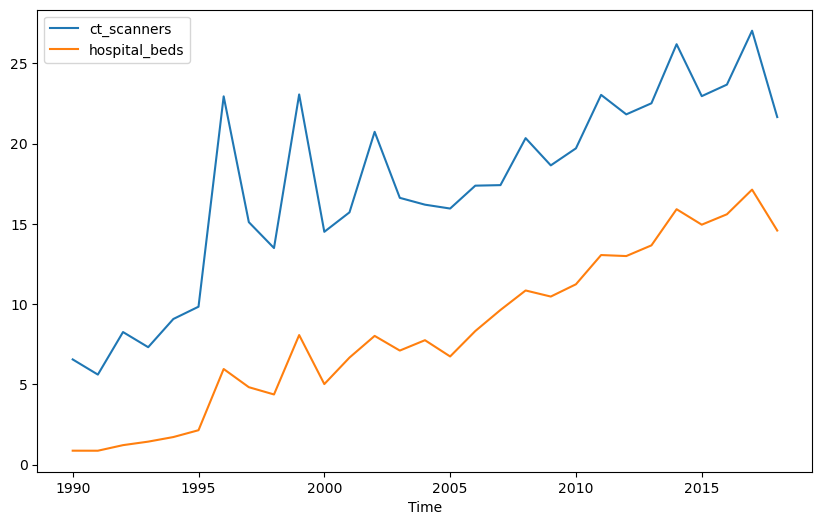

In [62]:
# adding time into the analysis 
df.groupby('Time')[['ct_scanners','hospital_beds']].mean().plot(figsize=(10,6))

In [59]:
# checking count for country
df[['country','hospital_beds']].value_counts(dropna=True)

country  hospital_beds
HUN      2.79             2
         2.57             2
         1.36             2
BEL      10.65            2
ISR      2.23             2
                         ..
FIN      18.65            1
         15.73            1
         15.32            1
         15.19            1
USA      39.03            1
Name: count, Length: 509, dtype: int64

In [63]:
#export df2 only numeric values 
df2.to_pickle(os.path.join(data_path,'Prepared Data','Cleaned only numeric.pkl'))